In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import zipfile
import pyarrow
from astropy.io import fits
from scipy.interpolate import interp1d

In [2]:
path = '/home/m/monroy/rubin-user/spectra_bt_dusty/'
main_file = 'bt_dusty.zip'
outdir = path

In [3]:
# Ruta al archivo .zip principal
main_zip = os.path.join(path,main_file)

# Directorio temporal para extraer los archivos .zip internos
temp_dir = os.path.join(path,'temp_zip')

# Crear el directorio temporal si no existe
os.makedirs(temp_dir, exist_ok=True)

# Extraer solo los archivos .zip del .zip principal
with zipfile.ZipFile(main_zip, 'r') as zip_ref:
    # Listar todos los archivos dentro del .zip principal
    all_files = zip_ref.namelist()

    # Filtrar solo los archivos .zip
    files_zip = [file_ for file_ in all_files if file_.endswith('.zip') and 'IR' not in file_]

    # Extraer solo los archivos .zip
    for file_ in files_zip:
        zip_ref.extract(file_, temp_dir)


In [4]:
a = fits.open(os.path.join(temp_dir,'P_s2000g2.50z0.0t0.10_a0.00c0.00n0.00o0.00_VIS.spec.FITS.zip'))

In [5]:
a[1].data

FITS_rec([( 3000.0254, 8.6258e-05, 8.2537e-07),
          ( 3000.0754, 9.7387e-05, 9.3164e-07),
          ( 3000.1254, 9.7185e-05, 9.2950e-07), ...,
          (11999.9467, 7.3672e+04, 4.5740e-01),
          (11999.9667, 8.2909e+04, 5.1475e-01),
          (11999.9867, 8.8186e+04, 5.4752e-01)],
         dtype=(numpy.record, [('wavelength', '>f8'), ('flux', '>f4'), ('normalized flux', '>f4')]))

In [6]:
with fits.open(os.path.join(temp_dir,files_zip[0])) as fits_file:
    print(files_zip[0])
    data_ = fits_file[1].data
    wl0 = data_['wavelength'].byteswap().newbyteorder()
    flux_ = data_['flux'].byteswap().newbyteorder()
    df = pd.DataFrame({
        'Wavelength':wl0,
        'Flux1':flux_
    })

P_s2000g2.00z0.0t0.10_a0.00c0.00n0.00o0.00_VIS.spec.FITS.zip


In [7]:
df

,Wavelength,Flux1
0,3000.0254,0.000068
1,3000.0754,0.000082
2,3000.1254,0.000086
3,3000.1754,0.000049
4,3000.2254,0.000034
...,...,...
390142,11999.9067,60968.000000
390143,11999.9267,65343.000000
390144,11999.9467,70486.000000
390145,11999.9667,75422.000000


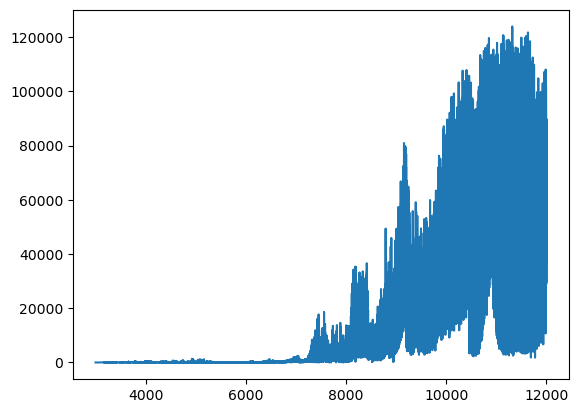

In [8]:
plt.plot(df['Wavelength'],df['Flux1'])

In [12]:
for i in range(1,len(files_zip)):
    with fits.open(os.path.join(temp_dir,files_zip[i])) as fits_file:
        data_ = fits_file[1].data
        wl_ = data_['Wavelength'].byteswap().newbyteorder()
        flux_ = data_['flux'].byteswap().newbyteorder()

        interp_func = interp1d(wl_,flux_, bounds_error=False, fill_value="extrapolate")
        flux_interpolated_ = interp_func(df['Wavelength'])
        df['Flux{0}'.format(i+1)] = flux_interpolated_

/tmp/ipykernel_4384/3434523935.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Flux{0}'.format(i+1)] = flux_interpolated_
/tmp/ipykernel_4384/3434523935.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Flux{0}'.format(i+1)] = flux_interpolated_
/tmp/ipykernel_4384/3434523935.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragment

In [13]:
df

,Wavelength,Flux1,Flux2,Flux3,Flux4,Flux5,Flux6,Flux7,Flux8,Flux9,...,Flux368,Flux369,Flux370,Flux371,Flux372,Flux373,Flux374,Flux375,Flux376,Flux377
0,3000.0254,0.000068,0.000086,0.000294,0.000760,0.000340,0.000075,0.000084,0.000196,0.000343,...,453840.0,416100.0,499460.0,732490.0,1745400.0,4166800.0,4668700.0,4868600.0,4656900.0,4055100.0
1,3000.0754,0.000082,0.000097,0.000296,0.001080,0.000469,0.000089,0.000090,0.000197,0.000342,...,358920.0,321140.0,374460.0,388780.0,409170.0,512980.0,623300.0,765070.0,933900.0,1139500.0
2,3000.1254,0.000086,0.000097,0.000292,0.001393,0.000564,0.000094,0.000089,0.000196,0.000339,...,854670.0,847230.0,1104300.0,3163000.0,3614100.0,4312200.0,4792900.0,5010700.0,4817300.0,4209200.0
3,3000.1754,0.000049,0.000073,0.000278,0.000740,0.000359,0.000075,0.000079,0.000191,0.000329,...,2179200.0,2311500.0,2926800.0,3123900.0,2882000.0,3153600.0,3383800.0,3488200.0,3392300.0,3081100.0
4,3000.2254,0.000034,0.000058,0.000264,0.000556,0.000260,0.000060,0.000070,0.000185,0.000319,...,2297700.0,2483100.0,3182700.0,4225700.0,4468900.0,5180800.0,5805000.0,6032500.0,5626000.0,4641900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390142,11999.9067,60968.000000,55271.000000,78325.000000,90033.000000,78922.000000,65494.000000,69470.000000,80334.000000,90636.000000,...,2295100.0,2310500.0,2404900.0,2409400.0,2432200.0,2440600.0,2444000.0,2431100.0,2432800.0,2452400.0
390143,11999.9267,65343.000000,63416.000000,85133.000000,95521.000000,87862.000000,79159.000000,81884.000000,86397.000000,93282.000000,...,2295100.0,2310500.0,2404900.0,2409400.0,2431600.0,2440600.0,2443400.0,2430500.0,2432200.0,2452400.0
390144,11999.9467,70486.000000,73672.000000,91306.000000,101790.000000,98492.000000,90719.000000,92300.000000,91685.000000,95653.000000,...,2295100.0,2310500.0,2404900.0,2409400.0,2431600.0,2440600.0,2443400.0,2430500.0,2432200.0,2451900.0
390145,11999.9667,75422.000000,82909.000000,97029.000000,107670.000000,107470.000000,101530.000000,101880.000000,96561.000000,98062.000000,...,2295100.0,2310500.0,2404900.0,2409400.0,2431600.0,2440100.0,2443400.0,2430500.0,2432200.0,2451900.0


In [14]:
df.to_parquet(os.path.join(outdir,'bt_dusty_spectra.parquet'), engine='pyarrow', compression='snappy')

In [15]:
# Limpiar el directorio temporal (opcional)
os.system(f'rm -rf {temp_dir}')

0

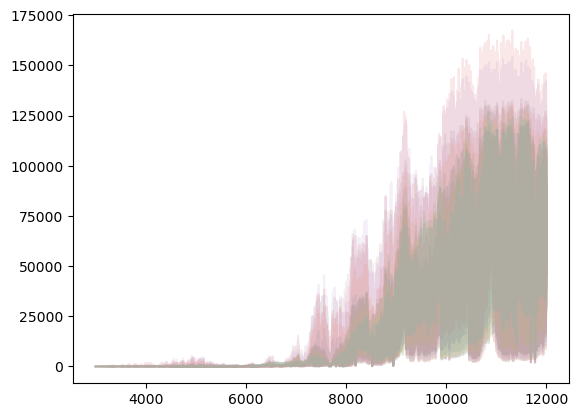

In [16]:
for i in range(1,11):
    plt.plot(df['Wavelength'][:],df['Flux{0}'.format(i)][:],alpha=0.1)